# a3ps — train the LSTM seq2seq forecaster (Colab)

Trains `Seq2SeqNet` (encoder/decoder LSTM, hidden 64, 2 layers) on the mined
trajectory windows (`data/trajectories/*.npz`). Gaussian-NLL loss, AdamW lr 1e-3,
30 epochs, early stop on val ADE. Saves best weights to `models/seq2seq_v1.pt`
(state_dict compatible with `a3ps.forecasting.seq2seq.Seq2SeqForecaster`).

Shards store **normalized** windows: history (N,10,2), future (N,20,2), with the
last-history point at the origin and heading rotated to +y.

In [1]:
!pip -q install torch numpy matplotlib
import os, glob, numpy as np, torch, torch.nn as nn
import matplotlib.pyplot as plt
torch.manual_seed(0); np.random.seed(0)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('device', device)


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


device cuda


In [2]:
# --- get the shards ---
# Option A: mount Drive and point SHARD_DIR at your uploaded trajectories folder.
# Option B: upload the .npz files (or a zip) to the Colab session and set SHARD_DIR.
try:
    from google.colab import drive; drive.mount('/content/drive')
    SHARD_DIR = '/content/drive/MyDrive/trajectories'
except Exception:
    SHARD_DIR = 'data/trajectories'   # local fallback
if not glob.glob(os.path.join(SHARD_DIR, '*.npz')):
    SHARD_DIR = input('Path to folder with *.npz shards: ').strip()
print('SHARD_DIR =', SHARD_DIR)

Path to folder with *.npz shards:  D:\Coding\FYP\A3PS_MAIN\a3ps\data\trajectories


SHARD_DIR = D:\Coding\FYP\A3PS_MAIN\a3ps\data\trajectories


In [3]:
# --- load + concatenate shards (sorted order, fixed val split) ---
SEED = 42; VAL_FRAC = 0.10
shards = sorted(glob.glob(os.path.join(SHARD_DIR, '*.npz')))
assert shards, f'no shards in {SHARD_DIR}'
H = np.concatenate([np.load(s)['history'] for s in shards]).astype('float32')
F = np.concatenate([np.load(s)['future'] for s in shards]).astype('float32')
print('windows:', len(H), '| history', H.shape[1:], '| future', F.shape[1:])
idx = np.random.default_rng(SEED).permutation(len(H))
n_val = max(1, int(len(H) * VAL_FRAC))
val_i, tr_i = idx[:n_val], idx[n_val:]
print(f'train {len(tr_i)}  val {len(val_i)}')

windows: 1725 | history (10, 2) | future (20, 2)
train 1553  val 172


In [4]:
# --- model (mirrors a3ps/forecasting/seq2seq.py so weights are compatible) ---
HIST, FUT, HIDDEN, LAYERS = 10, 20, 64, 2
class Seq2SeqNet(nn.Module):
    def __init__(self, hidden=HIDDEN, layers=LAYERS):
        super().__init__(); self.hidden=hidden; self.layers=layers
        self.encoder = nn.LSTM(2, hidden, layers, batch_first=True)
        self.decoder = nn.LSTM(2, hidden, layers, batch_first=True)
        self.delta_head = nn.Linear(hidden, 2)
        self.logvar_head = nn.Linear(hidden, 2)
    def forward(self, history, target_deltas=None, steps=FUT):
        b = history.size(0); _, hc = self.encoder(history)
        inp = history.new_zeros(b,1,2); pos = history.new_zeros(b,2)
        means, logvars = [], []
        for t in range(steps):
            out, hc = self.decoder(inp, hc); o = out[:,0]
            delta = self.delta_head(o); logvar = self.logvar_head(o)
            pos = pos + delta; means.append(pos); logvars.append(logvar)
            inp = target_deltas[:,t:t+1,:] if (target_deltas is not None and t < target_deltas.size(1)) else delta.unsqueeze(1)
        return torch.stack(means,1), torch.stack(logvars,1)

def future_to_deltas(fut):
    prev = torch.cat([fut.new_zeros(fut.size(0),1,2), fut[:,:-1]], 1); return fut - prev
def gaussian_nll(mp, lv, y):
    return 0.5*(lv + (y-mp)**2*torch.exp(-lv)).sum(-1).mean()
def ade_fde(mp, y):
    d = torch.linalg.norm(mp - y, dim=-1)  # (B,FUT)
    return d.mean().item(), d[:,-1].mean().item()

In [5]:
# --- train: AdamW 1e-3, 30 epochs, early stop on val ADE ---
Htr = torch.tensor(H[tr_i], device=device); Ftr = torch.tensor(F[tr_i], device=device)
Hva = torch.tensor(H[val_i], device=device); Fva = torch.tensor(F[val_i], device=device)
Dtr = future_to_deltas(Ftr)
model = Seq2SeqNet().to(device)
opt = torch.optim.AdamW(model.parameters(), lr=1e-3)
EPOCHS, BATCH, PATIENCE = 30, 256, 6
tr_loss, va_loss, va_ade = [], [], []
best_ade, best_state, bad = float('inf'), None, 0
for ep in range(EPOCHS):
    model.train(); perm = torch.randperm(len(Htr), device=device); tot=0.0
    for i in range(0, len(Htr), BATCH):
        b = perm[i:i+BATCH]
        mp, lv = model(Htr[b], target_deltas=Dtr[b])
        loss = gaussian_nll(mp, lv, Ftr[b])
        opt.zero_grad(); loss.backward(); opt.step(); tot += loss.item()*len(b)
    model.eval()
    with torch.no_grad():
        mp, lv = model(Hva)                 # free-running (no teacher forcing)
        vl = gaussian_nll(mp, lv, Fva).item(); ade, fde = ade_fde(mp, Fva)
    tr_loss.append(tot/len(Htr)); va_loss.append(vl); va_ade.append(ade)
    print(f'ep {ep:02d}  train_nll {tr_loss[-1]:.3f}  val_nll {vl:.3f}  val_ADE {ade:.3f}  val_FDE {fde:.3f}')
    if ade < best_ade - 1e-4:
        best_ade, best_state, bad = ade, {k:v.detach().cpu().clone() for k,v in model.state_dict().items()}, 0
    else:
        bad += 1
        if bad >= PATIENCE: print(f'early stop @ ep {ep} (best val ADE {best_ade:.3f})'); break
print('best val ADE:', round(best_ade,3))

ep 00  train_nll 4289.587  val_nll 4550.465  val_ADE 55.741  val_FDE 95.870
ep 01  train_nll 2914.639  val_nll 3866.860  val_ADE 55.159  val_FDE 95.180
ep 02  train_nll 1540.059  val_nll 1880.638  val_ADE 53.736  val_FDE 93.159
ep 03  train_nll 748.866  val_nll 425.652  val_ADE 52.437  val_FDE 90.811
ep 04  train_nll 302.952  val_nll 190.438  val_ADE 52.135  val_FDE 90.321
ep 05  train_nll 147.729  val_nll 108.855  val_ADE 52.040  val_FDE 90.353
ep 06  train_nll 89.997  val_nll 74.012  val_ADE 52.029  val_FDE 90.504
ep 07  train_nll 64.768  val_nll 56.331  val_ADE 52.057  val_FDE 90.693
ep 08  train_nll 50.632  val_nll 46.498  val_ADE 52.014  val_FDE 90.659
ep 09  train_nll 42.743  val_nll 40.278  val_ADE 51.949  val_FDE 90.542
ep 10  train_nll 37.536  val_nll 36.140  val_ADE 51.883  val_FDE 90.419
ep 11  train_nll 34.010  val_nll 33.086  val_ADE 51.855  val_FDE 90.393
ep 12  train_nll 31.346  val_nll 30.696  val_ADE 51.846  val_FDE 90.415
ep 13  train_nll 29.140  val_nll 28.746  val_A

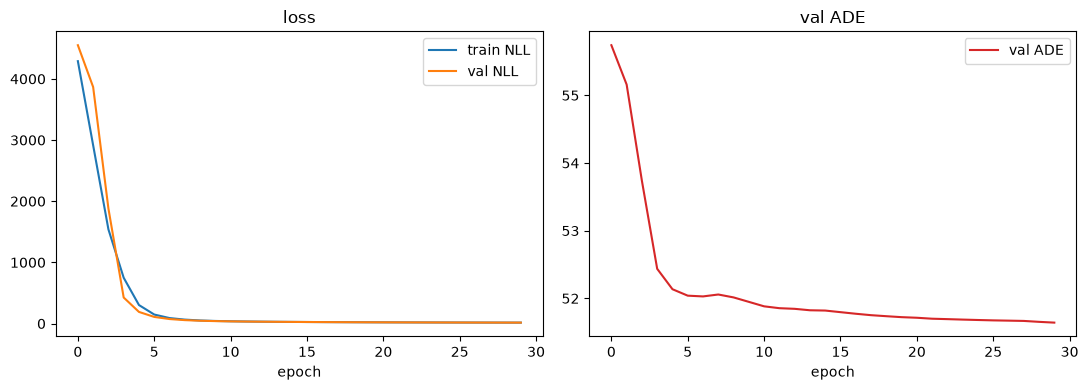

In [6]:
# --- loss curves ---
fig, ax = plt.subplots(1,2, figsize=(11,4))
ax[0].plot(tr_loss, label='train NLL'); ax[0].plot(va_loss, label='val NLL'); ax[0].legend(); ax[0].set_title('loss')
ax[1].plot(va_ade, label='val ADE', color='#d62728'); ax[1].legend(); ax[1].set_title('val ADE')
for a in ax: a.set_xlabel('epoch')
plt.tight_layout(); plt.show()

## Red dashed paths should roughly hug the gorud truths that are the green paths especially for straight /curved car motion

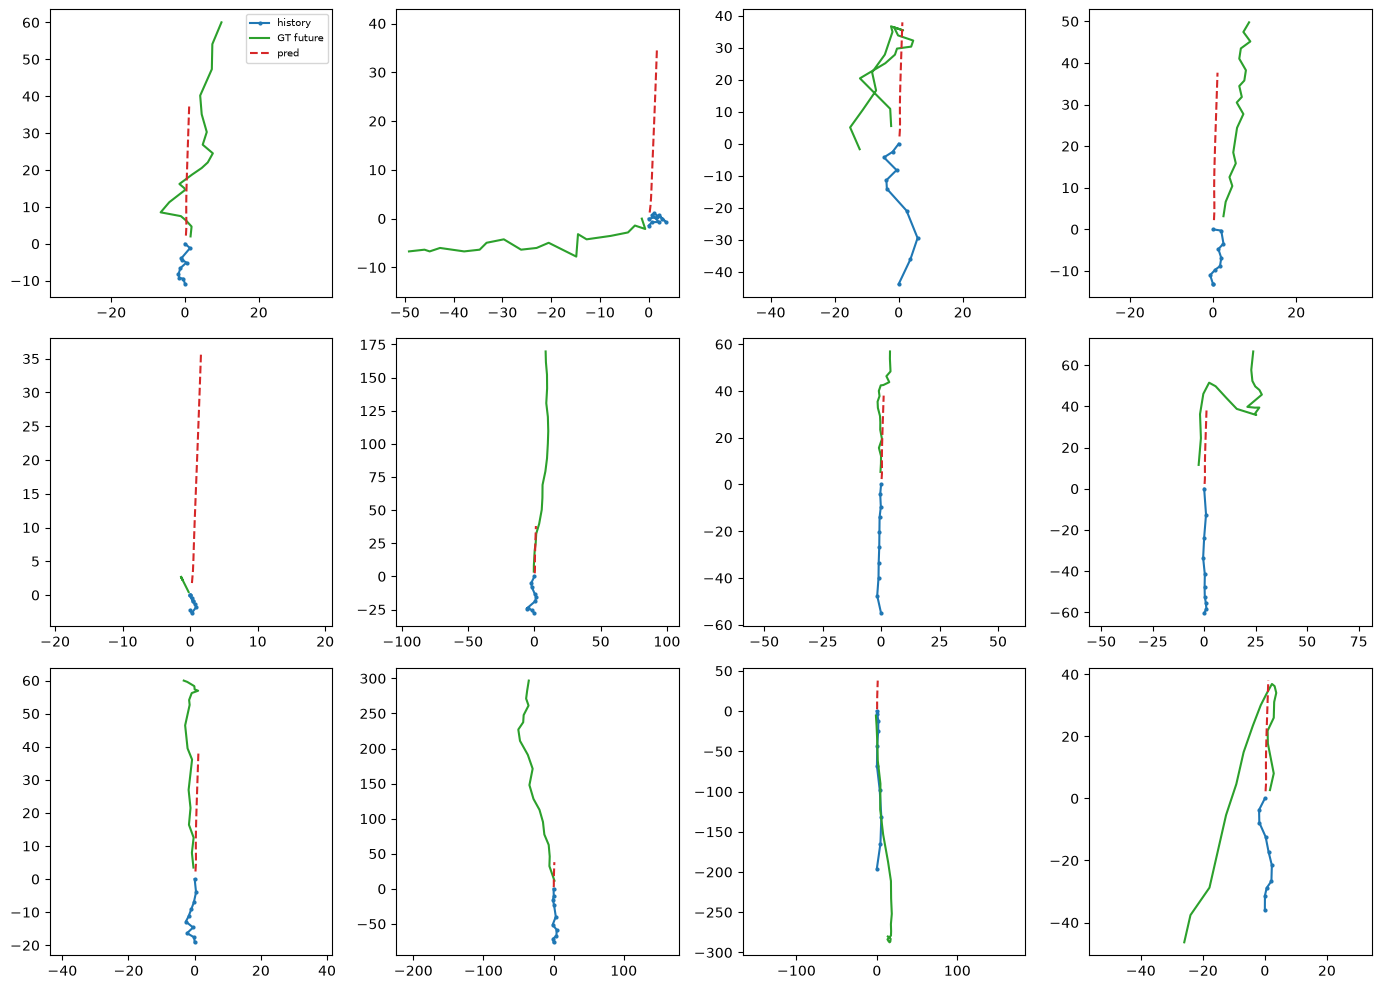

In [7]:
# --- 12 sample predictions vs ground truth ---
model.load_state_dict(best_state); model.eval()
with torch.no_grad():
    mp, _ = model(Hva[:12])
mp = mp.cpu().numpy(); hh = Hva[:12].cpu().numpy(); ff = Fva[:12].cpu().numpy()
fig, axs = plt.subplots(3,4, figsize=(14,10))
for k, ax in enumerate(axs.flat):
    ax.plot(hh[k,:,0], hh[k,:,1], '-o', ms=2, color='#1f77b4', label='history')
    ax.plot(ff[k,:,0], ff[k,:,1], '-', color='#2ca02c', label='GT future')
    ax.plot(mp[k,:,0], mp[k,:,1], '--', color='#d62728', label='pred')
    ax.set_aspect('equal', 'datalim')
    if k==0: ax.legend(fontsize=7)
plt.tight_layout(); plt.show()

In [8]:
# --- save best weights (compatible with Seq2SeqForecaster.load) ---
os.makedirs('models', exist_ok=True)
torch.save({'state_dict': best_state, 'hidden': HIDDEN, 'layers': LAYERS}, 'models/seq2seq_v1.pt')
print('saved models/seq2seq_v1.pt  (best val ADE', round(best_ade,3), ')')
# If on Colab, also copy to Drive so eval_forecast.py can pick it up:
# !cp models/seq2seq_v1.pt /content/drive/MyDrive/a3ps/

saved models/seq2seq_v1.pt  (best val ADE 51.642 )
